In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("zygmunt/goodbooks-10k")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'goodbooks-10k' dataset.
Path to dataset files: /kaggle/input/goodbooks-10k


In [ ]:
import os

base_path = "/root/.cache/kagglehub/datasets/zygmunt/goodbooks-10k/versions/5"

os.listdir(base_path)

['book_tags.csv',
 'to_read.csv',
 'tags.csv',
 'books.csv',
 'sample_book.xml',
 'ratings.csv']

In [ ]:
import pandas as pd

books = pd.read_csv(base_path + "/books.csv")

print(books.shape)
books.head()

(10000, 23)


,id,book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,...,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,...,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,...,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,...,3866839,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...
3,4,2657,2657,3275794,487,61120081,9.780061e+12,Harper Lee,1960.0,To Kill a Mockingbird,...,3198671,3340896,72586,60427,117415,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m...,https://images.gr-assets.com/books/1361975680s...
4,5,4671,4671,245494,1356,743273567,9.780743e+12,F. Scott Fitzgerald,1925.0,The Great Gatsby,...,2683664,2773745,51992,86236,197621,606158,936012,947718,https://images.gr-assets.com/books/1490528560m...,https://images.gr-assets.com/books/1490528560s...


In [ ]:
books.columns

Index(['id', 'book_id', 'best_book_id', 'work_id', 'books_count', 'isbn',
       'isbn13', 'authors', 'original_publication_year', 'original_title',
       'title', 'language_code', 'average_rating', 'ratings_count',
       'work_ratings_count', 'work_text_reviews_count', 'ratings_1',
       'ratings_2', 'ratings_3', 'ratings_4', 'ratings_5', 'image_url',
       'small_image_url'],
      dtype='object')

In [ ]:
ratings = pd.read_csv(base_path + "/ratings.csv")

In [ ]:
ratings.head()

,book_id,user_id,rating
0,1,314,5
1,1,439,3
2,1,588,5
3,1,1169,4
4,1,1185,4


In [ ]:
data = ratings.merge(books[['book_id','title']],on='book_id')

In [ ]:
data.head()

,book_id,user_id,rating,title
0,1,314,5,Harry Potter and the Half-Blood Prince (Harry ...
1,1,439,3,Harry Potter and the Half-Blood Prince (Harry ...
2,1,588,5,Harry Potter and the Half-Blood Prince (Harry ...
3,1,1169,4,Harry Potter and the Half-Blood Prince (Harry ...
4,1,1185,4,Harry Potter and the Half-Blood Prince (Harry ...


In [ ]:
user_item_matrix = data.pivot_table(index='user_id',
                                    columns='title',
                                    values='rating')
print(user_item_matrix.shape)

(28906, 812)


In [ ]:
books_similarity = user_item_matrix.corr(method='pearson')

In [ ]:
def recommend_books(book_name,n=5):
  if book_name not in books_similarity.columns:
    return "Book not found"
  similar_scores = books_similarity[book_name].sort_values(ascending=False)
  return similar_scores.iloc[1:n+1]

In [ ]:
recommend_books("The Hunger Games")

'Book not found'

In [ ]:
recommend_books("Harry Potter")

'Book not found'

In [ ]:
def recommend_books_partial(book_name, n=5):

    matches = [col for col in books_similarity.columns
               if book_name.lower() in col.lower()]

    if len(matches) == 0:
        return "Book not found"

    book_name = matches[0]

    similar_scores = books_similarity[book_name].sort_values(ascending=False)

    return similar_scores.iloc[1:n+1]

In [ ]:
recommend_books_partial("Hunger")

'Book not found'

In [ ]:
recommend_books_partial("Harry")

,"Harry Potter Boxed Set, Books 1-5 (Harry Potter, #1-5)"
title,
"Harry Potter Boxed Set, Books 1-5 (Harry Potter, #1-5)",1.0
"Ilium (Ilium, #1)",1.0
Ivanhoe,1.0
"Mayflower: A Story of Courage, Community, and War",1.0
"Men Are from Mars, Women Are from Venus",1.0


In [ ]:
recommend_books_partial("She")

,Do Androids Dream of Electric Sheep?
title,
"Practicing the Power of Now: Essential Teachings, Meditations, and Exercises from the Power of Now",1.0
Night Over Water,1.0
What Do You Care What Other People Think?,1.0
The Water-Method Man,1.0
The Valkyries,1.0


In [ ]:
recommend_books_partial("Her Power")

'Book not found'

In [ ]:
!pip install scikit-surprise

In [ ]:
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split
from surprise import accuracy

In [ ]:
!pip uninstall numpy -y
!pip install numpy==1.26.4

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 73.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26

In [ ]:
reader = Reader(rating_scale=(1,5))
data = Dataset.load_from_df(
    ratings[['user_id','book_id','rating']],
    reader
)
trainset,testset = train_test_split(data,test_size=0.2,random_state=42)

In [ ]:
model = SVD(n_factors=100,
            n_epochs=20,
            lr_all = 0.005,
            reg_all = 0.02)
model.fit(trainset)

In [ ]:
predictions = model.test(testset)
accuracy.rmse(predictions)

RMSE: 0.8443


0.844303518980662

In [ ]:
accuracy.mae(predictions)

MAE:  0.6601


0.6600914535628236

In [ ]:
model.predict(uid=1, iid=2767052)

Prediction(uid=1, iid=2767052, r_ui=None, est=3.8098070775691975, details={'was_impossible': False})

In [ ]:
def recommend_for_user(user_id,n=5):
  all_books = ratings['book_id'].unique()
  rated_books = ratings[ratings['user_id']==user_id]['book_id']
  books_to_predict = [book for book in all_books if book not in rated_books.values]
  predictions = [model.predict(user_id,book) for book in books_to_predict]
  predictions.sort(key=lambda x:x.est, reverse=True)
  top_books = [pred.iid for pred in predictions[:n]]
  return books[books['book_id'].isin(top_books)][['title','authors']]

In [ ]:
recommend_for_user(5)

,title,authors


# Analysis

In [ ]:
print("Book shape:", books.shape)
print("Ratings shape;",ratings.shape)

Book shape: (10000, 23)
Ratings shape; (981756, 3)


In [ ]:
books.head

<bound method NDFrame.head of          id  book_id  best_book_id   work_id  books_count        isbn  \
0         1  2767052       2767052   2792775          272   439023483   
1         2        3             3   4640799          491   439554934   
2         3    41865         41865   3212258          226   316015849   
3         4     2657          2657   3275794          487    61120081   
4         5     4671          4671    245494         1356   743273567   
...     ...      ...           ...       ...          ...         ...   
9995   9996  7130616       7130616   7392860           19   441019455   
9996   9997   208324        208324   1084709           19  067973371X   
9997   9998    77431         77431   2393986           60  039330762X   
9998   9999  8565083       8565083  13433613            7    61711527   
9999  10000     8914          8914     11817           31   375700455   

            isbn13                      authors  original_publication_year  \
0     9.780439e+12              Suzanne Collins                     2008.0   
1     9.780440e+12  J.K. Rowling, Mary GrandPré                     1997.0   
2     9.780316e+12              Stephenie Meyer                     2005.0   
3     9.780061e+12                   Harper Lee                     1960.0   
4     9.780743e+12          F. Scott Fitzgerald                     1925.0   
...            ...                          ...                        ...   
9995  9.780441e+12                Ilona Andrews                     2010.0   
9996  9.780680e+12               Robert A. Caro                     1990.0   
9997  9.780393e+12              Patrick O'Brian                     1977.0   
9998  9.780062e+12              Peggy Orenstein                     2011.0   
9999  9.780376e+12                  John Keegan                     1998.0   

                                         original_title  ... ratings_count  \
0                                      The Hunger Games  ...       4780653   
1              Harry Potter and the Philosopher's Stone  ...       4602479   
2                                              Twilight  ...       3866839   
3                                 To Kill a Mockingbird  ...       3198671   
4                                      The Great Gatsby  ...       2683664   
...                                                 ...  ...           ...   
9995                                         Bayou Moon  ...         17204   
9996                                   Means of Ascent   ...         12582   
9997                              The Mauritius Command  ...          9421   
9998  Cinderella Ate My Daughter: Dispatches from th...  ...         11279   
9999                                The First World War  ...          9162   

     work_ratings_count  work_text_reviews_count  ratings_1  ratings_2  \
0               4942365                   155254      66715     127936   
1               4800065                    75867      75504     101676   
2               3916824                    95009     456191     436802   
3               3340896                    72586      60427     117415   
4               2773745                    51992      86236     197621   
...                 ...                      ...        ...        ...   
9995              18856                     1180        105        575   
9996              12952                      395        303        551   
9997              10733                      374         11        111   
9998              11994                     1988        275       1002   
9999               9700                      364        117        345   

      ratings_3  ratings_4  ratings_5  \
0        560092    1481305    2706317   
1        455024    1156318    3011543   
2        793319     875073    1355439   
3        446835    1001952    1714267   
4        606158     936012     947718   
...         ...        ...        ...   
9995       3538       7860       6778   
99

In [ ]:
books.columns

Index(['id', 'book_id', 'best_book_id', 'work_id', 'books_count', 'isbn',
       'isbn13', 'authors', 'original_publication_year', 'original_title',
       'title', 'language_code', 'average_rating', 'ratings_count',
       'work_ratings_count', 'work_text_reviews_count', 'ratings_1',
       'ratings_2', 'ratings_3', 'ratings_4', 'ratings_5', 'image_url',
       'small_image_url'],
      dtype='object')

In [ ]:
ratings.columns

Index(['book_id', 'user_id', 'rating'], dtype='object')

<function matplotlib.pyplot.show(close=None, block=None)>

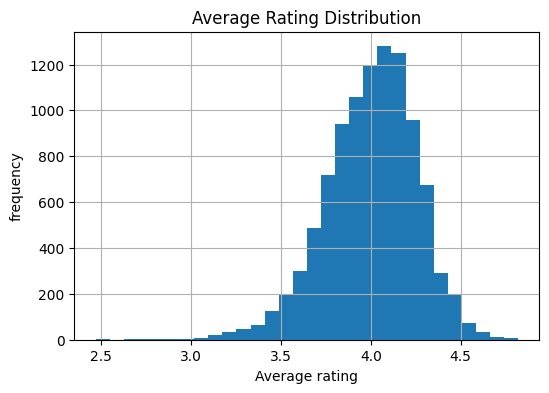

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
books["average_rating"].hist(bins=30)
plt.title("Average Rating Distribution")
plt.xlabel("Average rating")
plt.ylabel("frequency")
plt.show

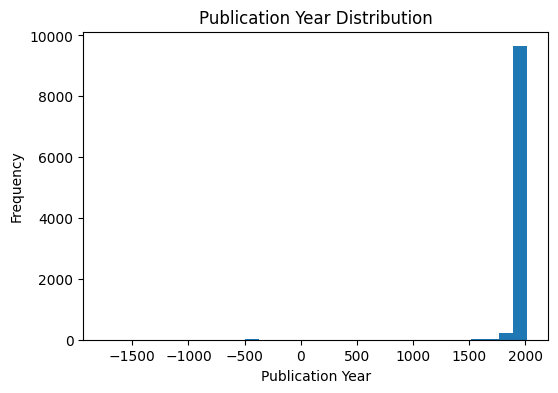

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(books["original_publication_year"],bins=30)
plt.title("Publication Year Distribution")
plt.xlabel("Publication Year")
plt.ylabel("Frequency")
plt.show()

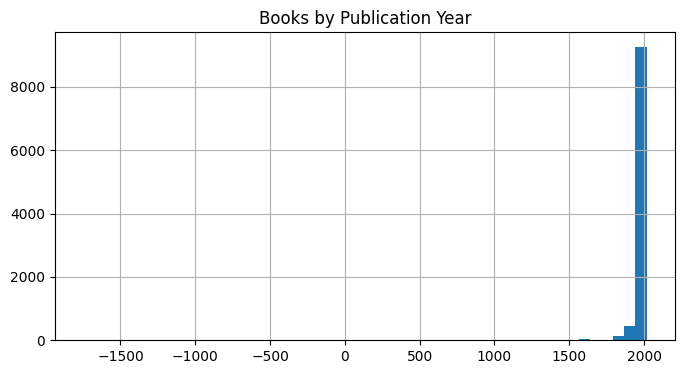

In [ ]:
plt.figure(figsize=(8,4))
books["original_publication_year"].dropna().hist(bins=50)
plt.title("Books by Publication Year")
plt.show()

In [ ]:
books.sort_values("ratings_count",ascending=False)[
    ["title","authors","ratings_count"]
].head(10)

,title,authors,ratings_count
0,"The Hunger Games (The Hunger Games, #1)",Suzanne Collins,4780653
1,Harry Potter and the Sorcerer's Stone (Harry P...,"J.K. Rowling, Mary GrandPré",4602479
2,"Twilight (Twilight, #1)",Stephenie Meyer,3866839
3,To Kill a Mockingbird,Harper Lee,3198671
4,The Great Gatsby,F. Scott Fitzgerald,2683664
5,The Fault in Our Stars,John Green,2346404
6,The Hobbit,J.R.R. Tolkien,2071616
7,The Catcher in the Rye,J.D. Salinger,2044241
9,Pride and Prejudice,Jane Austen,2035490
8,"Angels & Demons (Robert Langdon, #1)",Dan Brown,2001311


In [ ]:
popular = books[books["ratings_count"]>10000]
popular.sort_values("average_rating",ascending=False)[
    ["title","authors","ratings_count"]
].head(10)


,title,authors,ratings_count
3627,The Complete Calvin and Hobbes,Bill Watterson,28900
861,"Words of Radiance (The Stormlight Archive, #2)",Brandon Sanderson,73572
3274,"Harry Potter Boxed Set, Books 1-5 (Harry Potte...","J.K. Rowling, Mary GrandPré",33220
4482,It's a Magical World: A Calvin and Hobbes Coll...,Bill Watterson,22351
421,"Harry Potter Boxset (Harry Potter, #1-7)",J.K. Rowling,190050
6360,There's Treasure Everywhere: A Calvin and Hobb...,Bill Watterson,16766
6589,The Authoritative Calvin and Hobbes: A Calvin ...,Bill Watterson,16087
6919,The Indispensable Calvin and Hobbes,Bill Watterson,14597
3752,"Harry Potter Collection (Harry Potter, #1-6)",J.K. Rowling,24618
1307,A Court of Mist and Fury (A Court of Thorns an...,Sarah J. Maas,108384


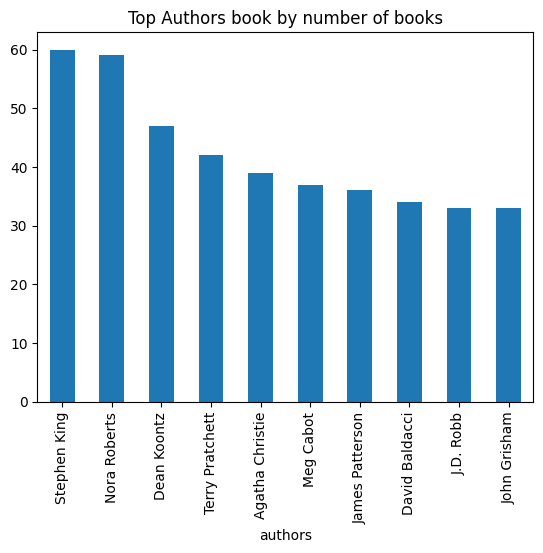

In [ ]:
top_authors = books["authors"].value_counts().head(10)
top_authors.plot(kind="bar")
plt.title("Top Authors book by number of books")
plt.show()

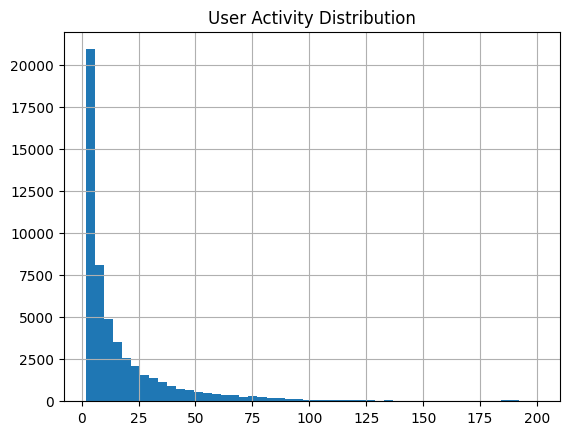

In [ ]:
user_activity = ratings.groupby("user_id")["rating"].count()

user_activity.hist(bins=50)
plt.title("User Activity Distribution")
plt.show()

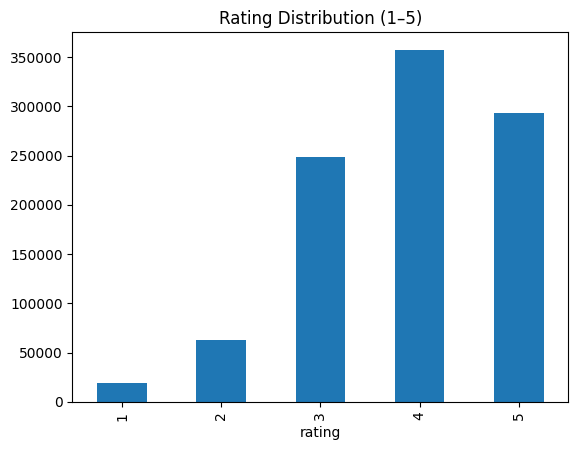

In [ ]:
ratings["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Rating Distribution (1–5)")
plt.show()

# Rating Prediction System

In [ ]:
data = ratings.merge(
    books[['book_id','average_rating','ratings_count','original_publication_year']],
    on='book_id'
)

data.head()

,book_id,user_id,rating,average_rating,ratings_count,original_publication_year
0,1,314,5,4.54,1678823,2005.0
1,1,439,3,4.54,1678823,2005.0
2,1,588,5,4.54,1678823,2005.0
3,1,1169,4,4.54,1678823,2005.0
4,1,1185,4,4.54,1678823,2005.0


In [ ]:
data.tail()

,book_id,user_id,rating,average_rating,ratings_count,original_publication_year
79696,9998,51295,5,3.91,11467,1962.0
79697,9998,51559,5,3.91,11467,1962.0
79698,9998,52087,4,3.91,11467,1962.0
79699,9998,52330,4,3.91,11467,1962.0
79700,9998,53249,5,3.91,11467,1962.0


In [ ]:
features = [
    'user_id',
    'book_id',
    'average_rating',
    'ratings_count',
    'original_publication_year'
]

X = data[features]
y = data['rating']

In [ ]:
from sklearn.preprocessing import LabelEncoder

user_encoder = LabelEncoder()
book_encoder = LabelEncoder()

X['user_id'] = user_encoder.fit_transform(X['user_id'])
X['book_id'] = book_encoder.fit_transform(X['book_id'])

/tmp/ipykernel_15537/1865300076.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['user_id'] = user_encoder.fit_transform(X['user_id'])
/tmp/ipykernel_15537/1865300076.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['book_id'] = book_encoder.fit_transform(X['book_id'])


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

preds = model.predict(X_test)

In [ ]:
rmse = mean_squared_error(y_test, preds)
print("RMSE:", rmse)

RMSE: 0.9387533355950303


In [ ]:
def predict_rating(user_id, book_id):

    user_enc = user_encoder.transform([user_id])[0]
    book_enc = book_encoder.transform([book_id])[0]

    book_info = books[books['book_id']==book_id].iloc[0]

    input_data = [[
        user_enc,
        book_enc,
        book_info['average_rating'],
        book_info['ratings_count'],
        book_info['original_publication_year']
    ]]

    return model.predict(input_data)[0]

In [ ]:
predict_rating(1169, 1)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


4.124295612429744